### 1. Preliminaries

In [2]:
import glob
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

try: import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *
from fastai.vision.all import *
set_seed(42)

# Set up paths
path = Path('/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets')

# Train images
train_path = path / 'train'
train_files = get_image_files(train_path)

# Test images
test_path = path / 'test'
test_files = get_image_files(test_path).sorted()

# Train labels
train_df = pd.read_csv(path / 'metadata-train.csv')
print(train_df.shape)
print(train_df.label.value_counts())

(4160, 4)
label
bacterial_leaf_blight       320
bacterial_leaf_streak       320
bacterial_panicle_blight    320
black_stem_borer            320
blast                       320
brown_spot                  320
downy_mildew                320
hispa                       320
leaf_roller                 320
normal                      320
tungro                      320
white_stem_borer            320
yellow_stem_borer           320
Name: count, dtype: int64


### 2. Dataloaders

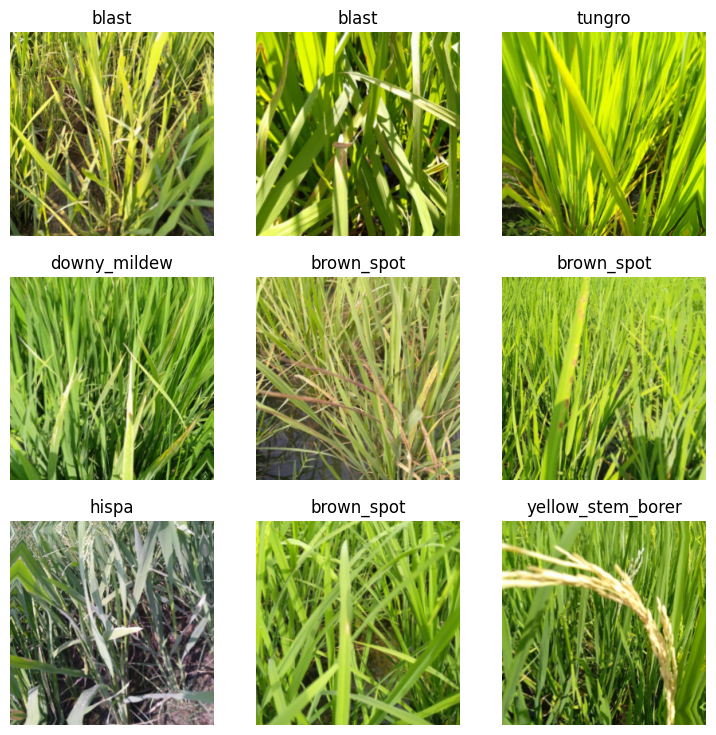

In [3]:
item_tfms = Resize(256)
batch_tfms = aug_transforms(
    do_flip=True, flip_vert=False, max_rotate=5.0, 
    max_zoom=1.2, max_warp=0.2, max_lighting=0.0, 
    p_affine=0.75, p_lighting=0.0
)

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=item_tfms,
    batch_tfms=batch_tfms
)

dls = dblock.dataloaders(path, bs=32)
dls.show_batch(max_n=9)


In [4]:
dls = ImageDataLoaders.from_folder(
    train_path, 
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),  # Simple resize without squishing
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

In [5]:
import wandb

wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

run = wandb.init(
    project="project-ablations",  # Customize as needed
    name="resnet50",
    config={
        "epochs": 100,
        "base_lr": 0.005,
        "weight_decay": 0.01,
        "architecture": "ResNet50"
    },
    reinit=True
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nigibril1 (nigibril1-gibril-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


### 3. Model training

In [ ]:
def get_layer_groups(model):
    return [model[0], model[1]]

learn = vision_learner(
    dls,
    resnet50,
    metrics=[
        accuracy,
        F1Score(average='macro')
    ],
    model_dir=Path("/kaggle/working/models")
)  # This is a writable location

# Let's first find a good learning rate
learn.lr_find()

# Based on lr_find results, use a moderate learning rate
learn.freeze()
learn.fit_one_cycle(5, 3e-3)

# Gradual unfreezing for more stable training
learn.unfreeze()
learn.fit_one_cycle(15, slice(1e-6, 1e-4))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.712098,2.196860,0.328125,0.327984,01:05
1,1.980623,1.770586,0.424279,0.426640,01:12
2,1.483753,1.527806,0.500000,0.504735,01:11
3,1.175314,1.424731,0.530048,0.533231,01:10
4,1.015077,1.396844,0.550481,0.553547,01:11


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.900957,1.413841,0.545673,0.550980,01:11
1,0.895006,1.366379,0.548077,0.554319,01:08
2,0.883789,1.187073,0.612981,0.616642,01:13
3,0.859496,1.293736,0.573317,0.579418,01:15


And that's it, 16 epochs to get the best baseline for the price 

In [ ]:
# learn.fine_tune(80, 0.005)
# #learn.fine_tune(2, 0.005)

# Fine-tune the model
# We'll use a discriminative learning rate and a one-cycle policy
# First, create a directory for models
from timm import create_model
from fastai.vision.all import vision_learner, error_rate
from fastai.callback.wandb import WandbCallback

import os
os.makedirs("/kaggle/working/models", exist_ok=True)

# Define all metrics first
learn = vision_learner(dls, resnet50, 
                      metrics=[error_rate, accuracy, 
                              Precision(average='macro'), 
                              Recall(average='macro'), 
                              F1Score(average='macro')],
                      model_dir=Path("/kaggle/working/models"))

# Now you can use fine_tune with callbacks that reference these metrics
learn.fine_tune(
    epochs=100,          
    base_lr=1e-3,       
    freeze_epochs=2,    
    cbs=[
        SaveModelCallback(monitor='f1_score', comp=np.greater, fname='resnet50_best_f1'),
        ShowGraphCallback(),
        EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=10),
        WandbCallback(log_model=True)

    ]
)

In [ ]:
wandb.save("resnet50_best_f1")

### 4. Predictions

In [ ]:
# Get predictions on validation set
probs, target = learn.get_preds(dl=dls.valid)
error_rate(probs, target)


In [ ]:
# Get TTA predictions on validation set
probs, target = learn.tta(dl=dls.valid)
error_rate(probs, target)

#### Predictions on test set

In [ ]:
# test images
test_path = path/'test'
test_files = get_image_files(test_path).sorted()
test_classes = [f.parent.name for f in test_files]

probs, _ = learn.tta(dl=dls.test_dl(test_files))
preds = probs.argmax(dim=1)
pred_classes = dls.vocab[preds]

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

cls_report = classification_report(test_classes, pred_classes, 
                                   digits=5)
print(cls_report)
acc = accuracy_score(test_classes, pred_classes)

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    #ax.set_title(title, fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

class_names = dls.vocab
plot_heatmap(test_classes, pred_classes, class_names, ax, title="Resnet50")    

#fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
#fig.tight_layout()
#fig.subplots_adjust(top=1.25)
plt.show()
cm = confusion_matrix(test_classes, pred_classes)
print(cm)

In [ ]:
temp = pd.DataFrame({"y_true":test_classes,
                      "y_pred":pred_classes})
temp.to_csv('result.csv', index=False)
temp

#### Acknowledgements
1. https://www.kaggle.com/code/fmussari/fast-resnet34-with-fastai
